In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('/home/hgf_hmgu/hgf_gib4562/tdmpc2')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from analysis.utils import reconstruct_cartpole_dmcontrol
from datetime import datetime
from itertools import product
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

sys.path.insert(0, '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2')
from tdmpc2 import TDMPC2
from projected_tdmpc2 import ProjectedTDMPC2
from tqdm import tqdm
from envs import make_env
from hydra import initialize, compose
from omegaconf import OmegaConf
from common.parser import parse_cfg
from common.seed import set_seed

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied



## Utils

In [80]:
def run_env_autonomous(env, initial_state, n_steps=100):
    obs = env.reset(initial_state=initial_state)
    #env.reset()
    obs_list = []
    obs_list.append(obs)
    for _ in range(n_steps - 1):
        next_obs, reward, done, info = env.step(torch.tensor([0.0]))
        obs_list.append(next_obs)

    return np.array(obs_list)


@torch.no_grad()
def run_dynamics_model(agent, env, initial_state, n_steps=100):
    obs = env.reset(initial_state=initial_state)
    z = agent.encode(obs.to(agent.device), task=None)

    obs_list = []
    obs_list.append(obs)
    z_list = []
    z_list.append(z.cpu().numpy())
    for _ in range(n_steps - 1):
        #next_obs, *_ = env.step(torch.tensor([0.0]))
        z = agent.model.next(z, torch.tensor([0.0]).to(agent.device), task=None)
        z_list.append(z.cpu().numpy())
        #obs_list.append(next_obs)

    return np.array(z_list)


@torch.no_grad()
def run_dynamics_model_in_steps(agent, env, initial_state, n_steps=100, k=10):
    obs = env.reset(initial_state=initial_state)
    z = agent.encode(obs.to(agent.device), task=None)
    obs_list = []
    z_list = []
    obs_list.append(obs)
    z_list.append(z.cpu().numpy())
    for step in range(0, n_steps - 1, k):
        steps_in_chunk = min(k, n_steps - 1 - step)
        for _ in range(steps_in_chunk):

            next_obs, *_ = env.step(torch.tensor([0.0]))
            z = agent.model.next(z,
                                 torch.tensor([0.0]).to(agent.device),
                                 task=None)

            z_list.append(z.cpu().numpy())
            obs_list.append(next_obs)
        z = agent.encode(next_obs.to(agent.device), task=None)
        #z_list.append(z.cpu().numpy())
    return np.array(z_list), np.array(obs_list)

In [45]:
CKPT_TO_USE = 500_000

## read data

In [67]:
from analysis.utils import load_sweep_metadata, load_data

df_metadata = load_sweep_metadata(
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-04-cartpole_swingup-model_sweep",
    json_file_name="episode_metadata.json",
)

df = load_data(
    df_metadata,
    episode_file_name="episode_data.pkl",
)

df['ckpt_int'] = df['checkpoint'].apply(
    lambda x: int(x.split('/')[-1].split('.')[0]))

df = df[df['ckpt_int'] == CKPT_TO_USE]
z_nonautonomous = np.concatenate(df['latent_states'].tolist())
obs_nonautonomous = np.concatenate(df['observations'].tolist())

Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-04-cartpole_swingup-model_sweep: 100%|██████████| 108/108 [00:00<00:00, 4651.53it/s]


Found 108 configurations
Found 108 configurations


  0%|          | 0/108 [00:00<?, ?it/s]

100%|██████████| 108/108 [00:04<00:00, 26.34it/s]


## Initialize environment and agent

In [68]:
# Base configuration
CKPT_PATH = f'logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/{CKPT_TO_USE}.pt'


def initialize_env_and_agent(ckpt_path, projector, seed=0):
    override_cfg = dict(
        task='cartpole-swingup',
        checkpoint=ckpt_path,
        obs='state',
        seed=seed,
        compile=False,
        mpc=True,
        multitask=False,
        model_size=5,
    )

    with initialize(config_path="tdmpc2", version_base=None):
        cfg = compose(config_name="config")
        OmegaConf.set_struct(cfg, False)
        cfg = OmegaConf.merge(cfg, override_cfg)

    # Parse config
    cfg = parse_cfg(cfg)
    set_seed(cfg.seed)

    cfg.initial_state = {
        'qpos': {
            'slider': 0,  # cart position
            'hinge_1': 0,  # pole angle
        },
    }

    env = make_env(cfg)

    print("\nLoading agent...")
    agent = ProjectedTDMPC2(cfg, projector)

    # Optionally load checkpoint
    if hasattr(cfg, 'checkpoint') and cfg.checkpoint:
        print(f"Loading checkpoint: {cfg.checkpoint}")
        agent.load(cfg.checkpoint)

    return env, agent, cfg

In [69]:
from pathlib import Path
from common.latent_projector import LatentProjector
from common.nonlinear_latent_projector import NonlinearLatentProjector

PROJECTORS_DIR = Path(
    '/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-23-cartpole_swingup-projected_sweep_uniform_data'
)


def get_projector_configs():
    """
    Define all projector configurations to sweep over.
    
    Returns list of dicts with:
        - name: Human-readable name for the config
        - path: Path to the projector file
        - type: 'linear' or 'nonlinear'
    """
    configs = []

    # Nonlinear projectors: k = 3, 4, 5, 6, 7, 8, 10, 15
    for k in [1, 2, 3, 4, 5, 6, 7, 8, 10, 15]:
        configs.append({
            'name': f'nonlinear_k{k}',
            'path': PROJECTORS_DIR / f'nonlinear_projector_k{k}.pt',
            'type': 'nonlinear',
            'method': 'nonlinear',
            'k': k,
        })

    return configs


def load_projector(config):
    """Load a projector from disk based on config."""
    path = config['path']
    if not path.exists():
        raise FileNotFoundError(
            f"Projector not found: {path}\n"
            f"Please fit projectors first and save them to {PROJECTORS_DIR}")

    if config['type'] == 'linear':
        return LatentProjector.load(str(path))
    else:  # nonlinear
        return NonlinearLatentProjector.load(str(path))


configs = get_projector_configs()


In [70]:
agents = {}
for config in configs:
    projector = load_projector(config)
    env, agent, cfg = initialize_env_and_agent(CKPT_PATH, projector)
    agents[(config['name'], config['k'])] = agent


NonlinearLatentProjector loaded: k=1, latent_dim=512

Loading agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/500000.pt
NonlinearLatentProjector loaded: k=2, latent_dim=512

Loading agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/500000.pt
NonlinearLatentProjector loaded: k=3, latent_dim=512

Loading agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/500000.pt
NonlinearLatentProjector loaded: k=4, latent_dim=512

Loading agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/500000.pt
NonlinearLatentProjector loaded: k=5, latent_dim=512

Loading agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/500000.pt
Nonli

In [71]:
def simulate_autonomous_data(env,
                             agent,
                             initial_positions=[0],
                             initial_angles=None,
                             steps_to_run=50):
    from itertools import product

    if initial_angles is None:
        initial_angles = np.linspace(0, 360, 11)

    obs = []
    z = []
    for initial_position, initial_angle in tqdm(
            product(initial_positions, initial_angles)):
        initial_angle_radians = np.radians(initial_angle)
        initial_state = {
            'qpos': {
                'slider': initial_position,  #cart position
                'hinge_1': initial_angle_radians,  # pole angle
            },
            'qvel': {
                #'slider': 0,  #cart velocity
                #'hinge_1': 0,  # pole angular velocity
            }
        }

        obs_true = run_env_autonomous(env, initial_state, steps_to_run)
        z_true = agent.encode(torch.from_numpy(obs_true).to(agent.device),
                              task=None).detach().cpu().numpy()

        obs.append(obs_true)
        z.append(z_true)

    return np.concatenate(obs), np.concatenate(z)

In [72]:
obs_autonomous, z_autonomous = simulate_autonomous_data(
    env,
    agent,
    initial_positions=[-1, 0, 1],
    initial_angles=None,
    steps_to_run=200)

33it [00:02, 14.99it/s]


In [73]:
obs_autonomous.shape, z_autonomous.shape

((6600, 5), (6600, 512))

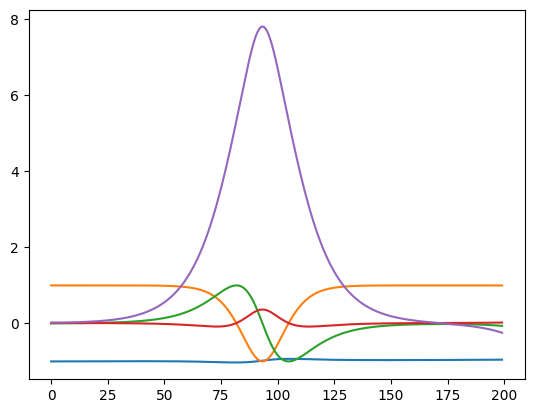

In [74]:
plt.plot(obs_autonomous[:200])
plt.show()

In [76]:
np.concatenate(z_autonomous, axis=0).shape

(3379200,)

In [77]:
z_autonomous.shape

(6600, 512)

R²: 0.9997


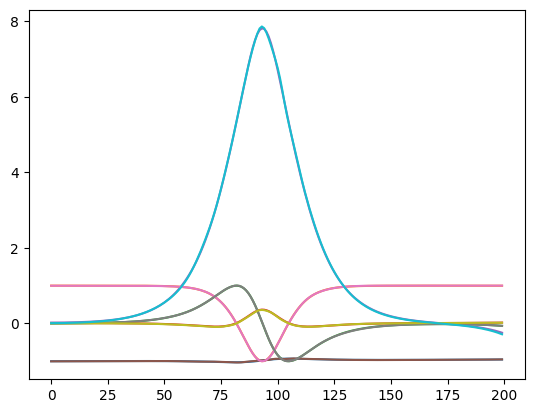

In [78]:
probe = LinearRegression().fit(z_autonomous, obs_autonomous)
y_pred = probe.predict(z_autonomous)
r2 = r2_score(obs_autonomous, y_pred)
print(f"R²: {r2:.4f}")
plt.plot(obs_autonomous[:200])
plt.plot(y_pred[:200])
plt.show()

In [103]:
intital_positions = [0]
initial_angles = np.linspace(0, 360, 3)[1:-1]
steps_to_run = 50

results = {}
for agent_name, agent in agents.items():

    results_agent = {}
    for initial_position, initial_angle in tqdm(
            product(intital_positions, initial_angles)):
        initial_angle_radians = np.radians(initial_angle)
        initial_state = {
            'qpos': {
                'slider': initial_position,  #cart position
                'hinge_1': initial_angle_radians,  # pole angle
            },
            'qvel': {
                'slider': 0,  #cart velocity
                'hinge_1': 0,  # pole angular velocity
            }
        }

        obs_true = run_env_autonomous(env, initial_state, steps_to_run)
        z_true = agent.encode(torch.from_numpy(obs_true).to(agent.device),
                              task=None).detach().cpu().numpy()

        z_predicted = run_dynamics_model(agent, env, initial_state,
                                         steps_to_run)
        obs_predicted = probe.predict(z_predicted)

        dict_results_steps = {}
        # for k in list(range(1, 10 + 1)) + [20] + [30] + [40] + [50]:
        #     z_predicted_steps, obs_true_steps = run_dynamics_model_in_steps(
        #         agent, env, initial_state, n_steps=steps_to_run, k=k)
        #     obs_predicted_steps = probe.predict(z_predicted_steps)
        #     dict_results_steps[f'z_predicted_steps_{k}'] = z_predicted_steps
        #     #dict_results_steps[f'obs_true_steps_{k}'] = obs_true_steps
        #     dict_results_steps[f'obs_predicted_steps_{k}'] = obs_predicted_steps

        errors_latent = (abs(z_true - z_predicted)).mean(1)
        errors_physical = (abs(obs_true - obs_predicted)).mean(1)
        error_physical_per_dim = [
            (abs(obs_true[:, i] - obs_predicted[:, i])).mean() for i in range(5)
        ]
        error_latent_per_dim = [
            (abs(z_true[:, i] - z_predicted[:, i])).mean() for i in range(512)
        ]
        r2_physical = r2_score(obs_true, obs_predicted)
        r2_physical_per_dim = [
            r2_score(obs_true[:, i], obs_predicted[:, i]) for i in range(5)
        ]
        r2_latent = r2_score(z_true, z_predicted)
        r2_latent_per_dim = [
            r2_score(z_true[:, i], z_predicted[:, i]) for i in range(512)
        ]

        r2_latent_per_time = [
            r2_score(z_true[i, :], z_predicted[i, :])
            for i in range(steps_to_run)
        ]
        variance_z_true_per_dim = np.var(z_true, axis=0)
        variance_z_predicted_per_dim = np.var(z_predicted, axis=0)
        variance_obs_true_per_dim = np.var(obs_true, axis=0)
        variance_obs_predicted_per_dim = np.var(obs_predicted, axis=0)

        results_agent[(initial_position, initial_angle)] = {
            'obs_true': obs_true,
            'obs_predicted': obs_predicted,
            'z_true': z_true,
            'z_predicted': z_predicted,
            **dict_results_steps,
            'errors_latent': errors_latent,
            'errors_physical': errors_physical,
            'error_physical_per_dim': error_physical_per_dim,
            'error_latent_per_dim': error_latent_per_dim,
            'r2_physical': r2_physical,
            'r2_physical_per_dim': r2_physical_per_dim,
            'r2_latent': r2_latent,
            'r2_latent_per_dim': r2_latent_per_dim,
            'r2_latent_per_time': r2_latent_per_time,
            'variance_z_true_per_dim': variance_z_true_per_dim,
            'variance_z_predicted_per_dim': variance_z_predicted_per_dim,
            'variance_obs_true_per_dim': variance_obs_true_per_dim,
            'variance_obs_predicted_per_dim': variance_obs_predicted_per_dim,
        }
    results[agent_name] = results_agent

0it [00:00, ?it/s]

/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/metrics/_regression.py:940: RuntimeWarning: overflow encountered in divide
  numerator[valid_score] / denominator[valid_score]
1it [00:00,  4.82it/s]
0it [00:00, ?it/s]/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/metrics/_regression.py:940: RuntimeWarning: overflow encountered in divide
  numerator[valid_score] / denominator[valid_score]
1it [00:00,  5.08it/s]
0it [00:00, ?it/s]/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/metrics/_regression.py:940: RuntimeWarning: overflow encountered in divide
  numerator[valid_score] / denominator[valid_score]
1it [00:00,  5.13it/s]
0it [00:00, ?it/s]/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/metrics/_regression.py:940: RuntimeWarning: overflow encountered in divide
  numerator[valid_score] / denominator[valid_score]
1it [00:00,  4.99it/s]
0i

In [104]:
results.keys()

dict_keys([('nonlinear_k1', 1), ('nonlinear_k2', 2), ('nonlinear_k3', 3), ('nonlinear_k4', 4), ('nonlinear_k5', 5), ('nonlinear_k6', 6), ('nonlinear_k7', 7), ('nonlinear_k8', 8), ('nonlinear_k10', 10), ('nonlinear_k15', 15)])

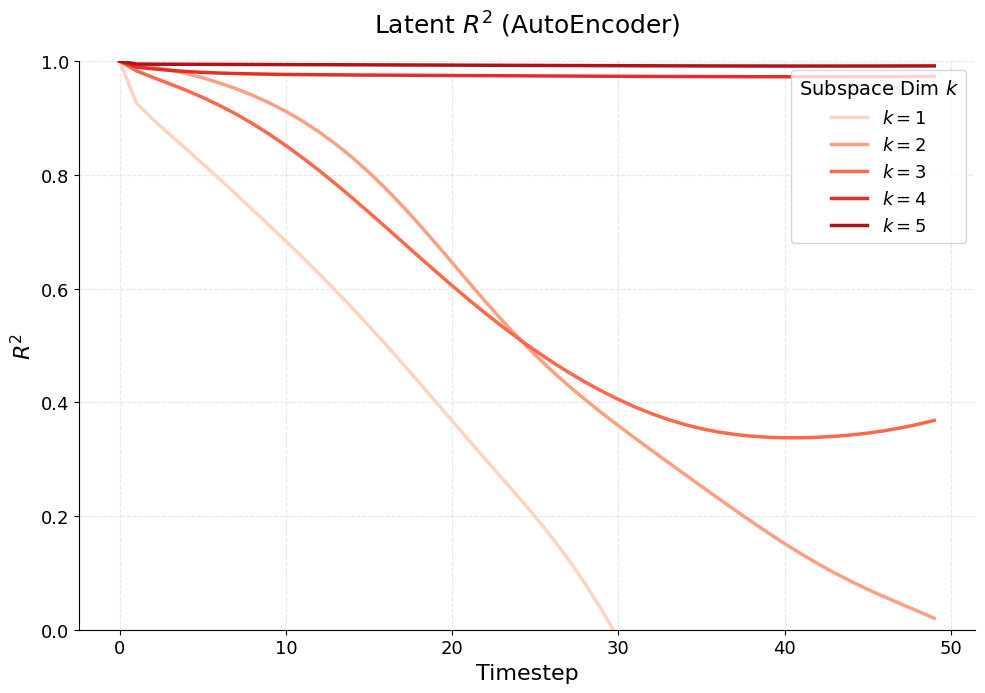

In [105]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Make a super nice figure for R2 latent per time, red colormap
plt.figure(figsize=(10, 7))

# Create a red colormap
cmap = plt.cm.get_cmap('Reds')
ks = sorted([k for k in results.keys() if k[1] < 6], key=lambda x: x[1])
num_lines = len(ks)
colors = [cmap(float(i + 1) / (num_lines + 1)) for i in range(num_lines)]

for idx, k in enumerate(ks):
    r2_time = results[k][(0, 180)]['r2_latent_per_time']
    plt.plot(r2_time, label=f'$k={k[1]}$', color=colors[idx], linewidth=2.5)

plt.xlabel("Timestep", fontsize=16)
plt.ylabel("$R^2$", fontsize=16)
plt.title("Latent $R^2$ (AutoEncoder)", fontsize=18, pad=20)
plt.legend(title="Subspace Dim $k$",
           fontsize=13,
           title_fontsize=14,
           loc="upper right",
           frameon=True)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.ylim(0, 1)
plt.tick_params(axis='both', which='major', labelsize=13)

# Remove top and right spines for a nice look
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.show()